In [1]:

import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
# from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt
import seaborn as sns

import math
import plotly.express as px


In [2]:
df = pd.read_csv("../../data/papers.csv")
total_papers = len(df)
df.columns

Index(['Title', 'Database', 'Year', 'Month', 'Journal or Conference',
       'Paper Type', 'Data Source', 'Data Country', 'Data Domain',
       'Data Language', 'Data Availability', 'Link to Data', 'Data Details',
       'Size', 'Number of Prompts If Applicable', 'Medical Application',
       'Task Type', 'Topic', 'Note', 'Bias Evaluation Metric',
       'Bias Definition', 'Conclusions', 'Race or Ethnic Bias', 'Gender Bias',
       'Language Bias', 'Age Bias', 'Other Bias', 'LGBTQ+ Bias',
       'Disability Bias', 'Geography or Cultural Bias', 'Evaluated LLMs',
       'Reference Standard', 'Patient Inclusion', 'Has Debiasing',
       'Debias Focus', 'Debiasing Method', 'Debias Details'],
      dtype='object')

In [3]:
language_groups_lst = df["Language Bias"].tolist()
language_groups_freqs = defaultdict(int)

for s in language_groups_lst:
    
    if isinstance(s, float):
        language_groups_freqs[str(s)] += 1
        continue
    
    s = s.strip().lower()
    s = s.replace("_", " ")
    
    if s == "no":
        language_groups_freqs[s] += 1
        continue
    
    match = re.search(r'\((.*?)\)', s)
    if not match:
        continue   # skip malformed rows safely
    
    items = match.group(1)   # <-- only inside parentheses
    languages = [lang.strip() for lang in items.split(',')]
    
    for language in languages:
        language_groups_freqs[language] += 1
        

In [4]:
language_groups_freqs.pop("no", None)

language_groups_freqs["english"] += language_groups_freqs.pop("aave", 0)
language_groups_freqs["english"] += language_groups_freqs.pop("standard english", 0)

for k in ["saudi arabic", "egyptian arabic", "lebanese arabic", "moroccan arabic"]:
    language_groups_freqs["arabic"] += language_groups_freqs.pop(k, 0)

language_groups_freqs["chinese"] += language_groups_freqs.pop("traditional chinese", 0)
language_groups_freqs["chinese"] += language_groups_freqs.pop("simplified chinese", 0)

language_groups_freqs["portuguese"] += language_groups_freqs.pop("brazilian portuguese", 0)
del language_groups_freqs["portuguese"]

for k in ["nan", ""]:
    language_groups_freqs.pop(k, None)

bar_graph_language_groups_freqs = dict(
    sorted(
        language_groups_freqs.items(),
        key=lambda item: item[1],
        reverse=True,
    )
)

print(bar_graph_language_groups_freqs.keys())
print(bar_graph_language_groups_freqs.values())
print(bar_graph_language_groups_freqs)


dict_keys(['english', 'arabic', 'chinese', 'spanish', 'japanese', 'non-arabic', 'polish', 'kazakh', 'russian', 'dutch'])
dict_values([13, 6, 4, 4, 2, 1, 1, 1, 1, 1])
{'english': 13, 'arabic': 6, 'chinese': 4, 'spanish': 4, 'japanese': 2, 'non-arabic': 1, 'polish': 1, 'kazakh': 1, 'russian': 1, 'dutch': 1}


/var/folders/04/2hwl1j9x5yl1hdpnd9k3jlqw0000gn/T/ipykernel_71897/3148479146.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=label_rotation, ha="right")


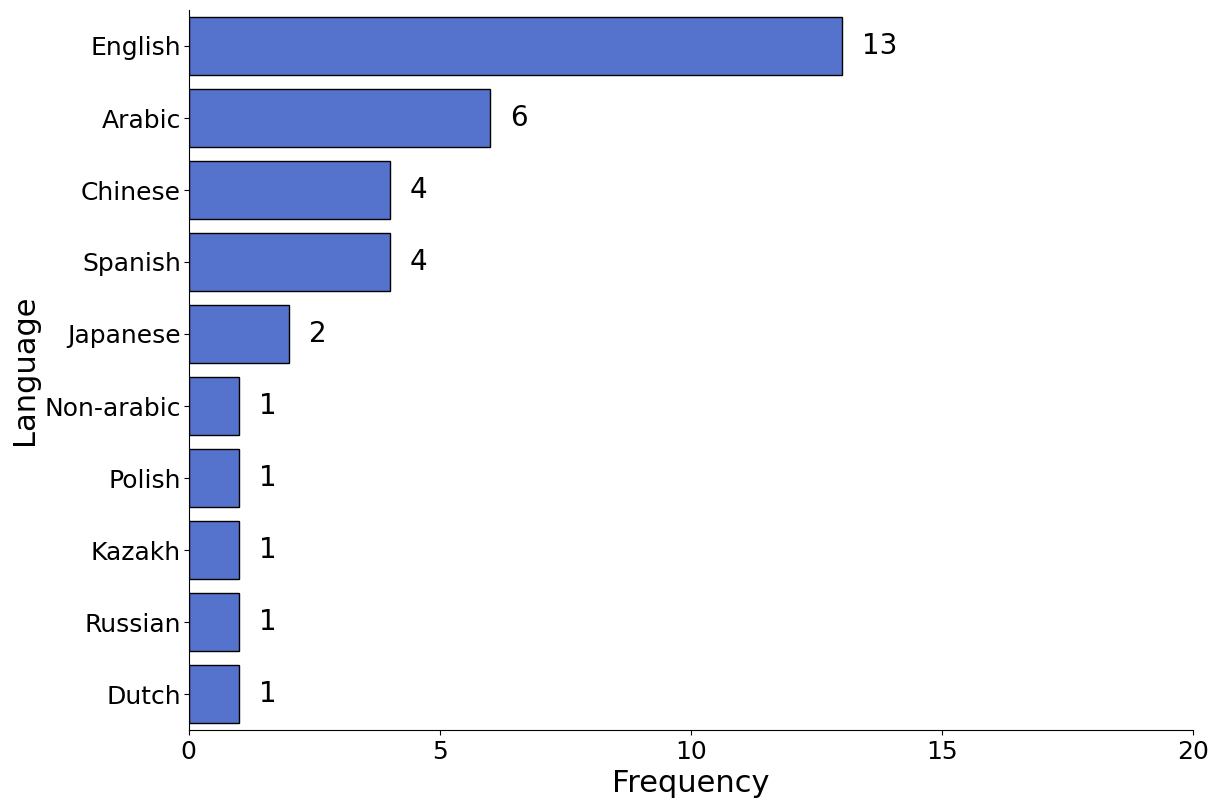

In [5]:
def smart_title(s: str) -> str:
    return " ".join(w.capitalize() for w in s.split())

label_rotation = 0
x_tick_labelsize = 18
SHOW_AXIS_TITLES = True
axis_title_fontsize = 22
count_label_pad = 0.4
count_label_fontsize = 20
SAVE_SVG = True
svg_path = "languages_to_frequencies.svg"
ylabel = "Language"
freq_var = bar_graph_language_groups_freqs

sorted_freqs = dict(sorted(freq_var.items(), key=lambda kv: kv[1], reverse=True))
groups = list(sorted_freqs.keys())
counts = list(sorted_freqs.values())
plot_df = pd.DataFrame({"group": [smart_title(g) for g in groups], "count": counts})

n_cats = len(groups)
fig, ax = plt.subplots(figsize=(12, max(8, 0.38 * n_cats)))

sns.barplot(
    data=plot_df,
    y="group",
    x="count",
    ax=ax,
    color="royalblue",
    edgecolor="black",
    linewidth=1,
    order=plot_df["group"],
)
sns.despine(ax=ax)

xmax_plot = int(math.ceil(max(counts) / 5.0)) * 5 + 5 if counts else 10
x_step = 10 if xmax_plot >= 40 else 5
x_gap = count_label_pad

for i, count in enumerate(counts):
    ax.text(count + x_gap, i, f"{count}", ha="left", va="center", fontsize=count_label_fontsize)

ax.set_xlim(0, xmax_plot)
ax.set_xticks(range(0, xmax_plot + 1, x_step))

if SHOW_AXIS_TITLES:
    ax.set_xlabel("Frequency", fontsize=axis_title_fontsize)
    ax.set_ylabel(ylabel, fontsize=axis_title_fontsize, labelpad=4)

ax.tick_params(axis="x", labelsize=x_tick_labelsize)
ax.tick_params(axis="y", labelsize=x_tick_labelsize, pad=2)
ax.set_yticklabels(ax.get_yticklabels(), rotation=label_rotation, ha="right")

longest = max((len(str(t.get_text())) for t in ax.get_yticklabels()), default=10)
fig.subplots_adjust(
    left=min(0.38, max(0.11, 0.085 + 0.0058 * longest)),
    right=0.98,
    top=0.98,
    bottom=0.08,
)
if SAVE_SVG:
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
fig.savefig("languages_to_frequencies.png", dpi=200, bbox_inches="tight")
plt.show()